# 서울 공공자전거 따릉이 수요 예측
### 시계열 모델 기반 정류소 재배치 전략

**Group 2** | 2026 Spring Time Series Analysis

---
> **[발표 순서]**  
> 1. 서론 — 문제 정의, 평가 지표  
> 2. 데이터 — 출처, 결측치, 2023+ 선택  
> 3. EDA — S=24 / 평일·주말 분리 / 외생변수 근거  
> 4. 모델링 — SARIMA, ARIMAX, RF, XGBoost  
> 5. 결과 비교  
> 6. Limitation & 결론

In [50]:
import sys, warnings, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.graphics.tsaplots import plot_acf
warnings.filterwarnings("ignore")

In [51]:
# presentation/ 에서 실행 시 부모 디렉토리(99_bicycle-demand-forecase/)를 경로에 추가
_cwd = Path(os.getcwd())
PROJECT_DIR = _cwd.parent if _cwd.name == "presentation" else _cwd
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.config import DATA_DIR, TARGET_RENT_ID, TARGET_RENT_IDS
from src.utils import load_filtered_csvs, make_series, load_weather
try:
    from src.utils import load_weather_full
    weather_df = load_weather_full(DATA_DIR)
    HAS_RAIN = True
except Exception:
    weather_df = load_weather(DATA_DIR)
    HAS_RAIN = False

import matplotlib.font_manager as fm
_korean_fonts = ["Malgun Gothic", "AppleGothic", "NanumGothic"]
_available = {f.name for f in fm.fontManager.ttflist}
_font = next((f for f in _korean_fonts if f in _available), "DejaVu Sans")

plt.rcParams["font.family"]       = _font
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지
plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.figsize"]    = (12, 4)

print(f"PROJECT_DIR: {PROJECT_DIR}")
print(f"DATA_DIR   : {DATA_DIR}")
print(f"한글 폰트  : {_font}")

PROJECT_DIR: c:\pjy\SNU\2026Q1\time-series\2026-Spring-TimeSeries-Group2\99_bicycle-demand-forecase
DATA_DIR   : c:\pjy\SNU\2026Q1\time-series\2026-Spring-TimeSeries-Group2\99_bicycle-demand-forecase\data
한글 폰트  : Malgun Gothic


In [52]:
# ── 데이터 로드 (시간 소요) ────────────────────────────────────
print("CSV 로드 중... (잠시 기다려주세요)")
df_raw  = load_filtered_csvs(DATA_DIR)                   # 전체 기간
df_2023 = df_raw[df_raw["datetime"].dt.year >= 2023]     # COVID 제외
series  = make_series(df_2023, TARGET_RENT_ID)           # 대표 정류소 02128
print(f"전체: {len(df_raw):,}건 | 2023+: {len(df_2023):,}건")
print(f"기상 컬럼: {weather_df.columns.tolist()}")
print("완료")


CSV 로드 중... (잠시 기다려주세요)
전체: 439,021건 | 2023+: 260,376건
기상 컬럼: ['temp', 'rainfall']
완료


---
## 1. 서론
> **[발표]** 따릉이 재배치 문제를 소개하고, 왜 예측이 필요한지 설명한다.  
> 핵심: *자전거가 없으면 아예 못 빌린다 → 과소예측이 더 큰 손해*

### 문제 정의

- **목표**: 23개 정류소 시간별 대여 수요 예측 → 재배치 전략 수립
- **핵심 지표**: Asymmetric RMSE (α=2) — 과소예측(자전거 고갈)에 **2배 패널티**

$$L(\hat{y}, y) = \begin{cases} \alpha \cdot (\hat{y} - y)^2 & \hat{y} < y \ (\text{과소예측}) \\ (\hat{y} - y)^2 & \hat{y} \geq y \ (\text{과대예측}) \end{cases}$$

> **왜 α=2?** 자전거가 없으면 수요 자체가 censored — 실제 수요보다 항상 낮게 관측됨

---
## 2. 데이터
> **[발표]** 데이터 출처 → 결측치 처리 → 왜 2023+만 쓰는지 순서로 설명

### 데이터 출처

| 데이터 | 출처 | 내용 |
|--------|------|------|
| 대여이력 | 서울 열린데이터광장 OA-15182 | 시간별 정류소 대여 건수 |
| 기상 | 기상청 서울 관측소 (108번) | 시간별 기온, 강수량 |

- 분석 대상: 서울대 인근 **23개 정류소**, 2023.01 ~ 2024.12
- 집계 단위: **1시간**

### 결측치 탐지 메커니즘

**"하루 전체가 비어있을 때만 결측"** 기준을 사용한 이유:

| 구분 | 판정 | 이유 |
|------|------|------|
| 심야(0~5시) 대여 0건 | **정상** | 실제 수요가 없는 것 |
| 특정 시간대만 0건 | **정상** | 수요 변동의 일부 |
| 하루 24시간 전체 레코드 없음 | **결측** | 데이터 수집 자체가 누락 |

```
결측률(%) = (전체 날짜 수 − 정류소에 레코드가 있는 날 수) / 전체 날짜 수 × 100
```

> 단순히 CNT=0인 행을 결측으로 보면 심야 정상 데이터가 결측으로 오분류됨 → 날짜 단위 판정이 핵심

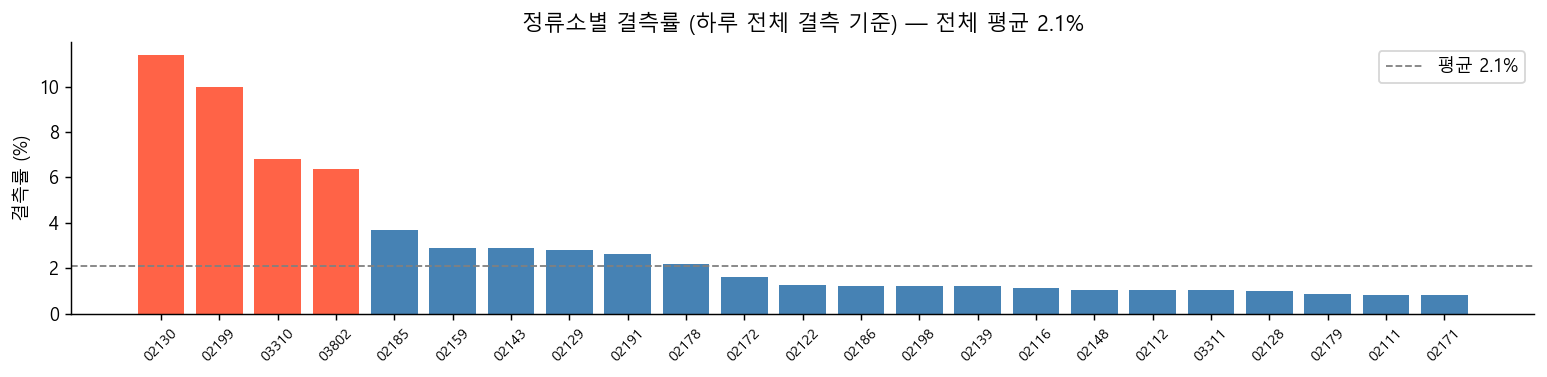

In [53]:

# ── 결측치 현황 시각화 ─────────────────────────────────────────────
# [발표] "결측률 2.1% — 하루 전체가 비어있을 때만 결측으로 판정"
#        "심야 0건은 정상 데이터이므로 결측으로 보지 않음"

from src.config import TARGET_RENT_IDS

# 날짜 컬럼 생성 (결측 판정의 단위: 하루)
df_raw['date'] = df_raw['datetime'].dt.date

# 전체 기간의 날짜 범위 생성 (기대 날짜 수 계산용)
all_dates  = pd.date_range(df_raw['datetime'].min().date(),
                            df_raw['datetime'].max().date(), freq='D')
total_days = len(all_dates)

# 정류소별로 실제 대여 기록이 있는 날 수를 세어 결측일 계산
miss_data = []
for rid in TARGET_RENT_IDS:
    observed_days = df_raw[df_raw['RENT_ID'] == rid]['date'].nunique()
    missing_days  = total_days - observed_days
    miss_data.append({
        'station': rid,
        'pct': missing_days / total_days * 100   # 결측률 (%)
    })

# 결측률 높은 순으로 정렬
miss_df = pd.DataFrame(miss_data).sort_values('pct', ascending=False)

# ── 시각화 ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 3))

# 5% 초과 정류소(심각)는 빨간색, 나머지는 파란색으로 구분
bar_colors = ['tomato' if p > 5 else 'steelblue' for p in miss_df['pct']]
ax.bar(miss_df['station'], miss_df['pct'], color=bar_colors)

# 전체 평균 결측률 기준선
ax.axhline(2.1, color='gray', linestyle='--', linewidth=1, label='평균 2.1%')
ax.set_ylabel('결측률 (%)')
ax.set_title('정류소별 결측률 (하루 전체 결측 기준) — 전체 평균 2.1%')
ax.legend()
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
# ── 2023+ 학습 데이터 기준 결측률 ─────────────────────────────────
# [발표] "학습에 실제로 사용하는 2023+ 구간 기준 결측률은 2.89%"
#        "02130·02199·03310은 10% 안팎 — 해당 정류소 예측 해석 시 주의"

df_2023['date'] = df_2023['datetime'].dt.date

start      = df_2023['datetime'].min().date()
end        = df_2023['datetime'].max().date()
all_d      = pd.date_range(start, end, freq='D')
total_days = len(all_d)

rows = []
for rid in TARGET_RENT_IDS:
    observed = df_2023[df_2023['RENT_ID'] == rid]['date'].nunique()
    missing  = total_days - observed
    rows.append({'정류소': rid, '결측일': missing,
                 '결측률(%)': round(missing / total_days * 100, 1)})

miss_df2    = pd.DataFrame(rows).sort_values('결측률(%)', ascending=False).reset_index(drop=True)
overall_pct = miss_df2['결측일'].sum() / (total_days * len(TARGET_RENT_IDS)) * 100

print(f'기간: {start} ~ {end}  |  전체 평균 결측률: {overall_pct:.2f}%')
print()
print(miss_df2.to_string(index=False))

# ── 시각화 ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 왼쪽: 정류소별 결측률 막대
bar_colors = ['tomato' if p > 5 else ('orange' if p > 2 else 'steelblue')
              for p in miss_df2['결측률(%)']]
axes[0].bar(miss_df2['정류소'], miss_df2['결측률(%)'], color=bar_colors)
axes[0].axhline(overall_pct, color='gray', linestyle='--', linewidth=1,
                label=f'평균 {overall_pct:.1f}%')
axes[0].set_ylabel('결측률 (%)')
axes[0].set_title(f'정류소별 결측률 — 2023+ 학습 데이터 기준\n전체 평균 {overall_pct:.2f}%')
axes[0].legend()
plt.setp(axes[0].get_xticklabels(), rotation=45, fontsize=8)

# 오른쪽: 결측률 구간별 정류소 수
bins   = [0, 1, 2, 5, 10, 100]
labels = ['<1%', '1~2%', '2~5%', '5~10%', '>10%']
counts = pd.cut(miss_df2['결측률(%)'], bins=bins, labels=labels,
                include_lowest=True).value_counts().reindex(labels)
bar_c2 = ['steelblue', 'steelblue', 'orange', 'tomato', 'tomato']
axes[1].bar(labels, counts.values, color=bar_c2)
for bar, v in zip(axes[1].patches, counts.values):
    if v > 0:
        axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.05,
                     str(v), ha='center', va='bottom', fontweight='bold')
axes[1].set_ylabel('정류소 수')
axes[1].set_title('결측률 구간별 정류소 분포\n(23개 정류소)')

plt.tight_layout()
plt.show()

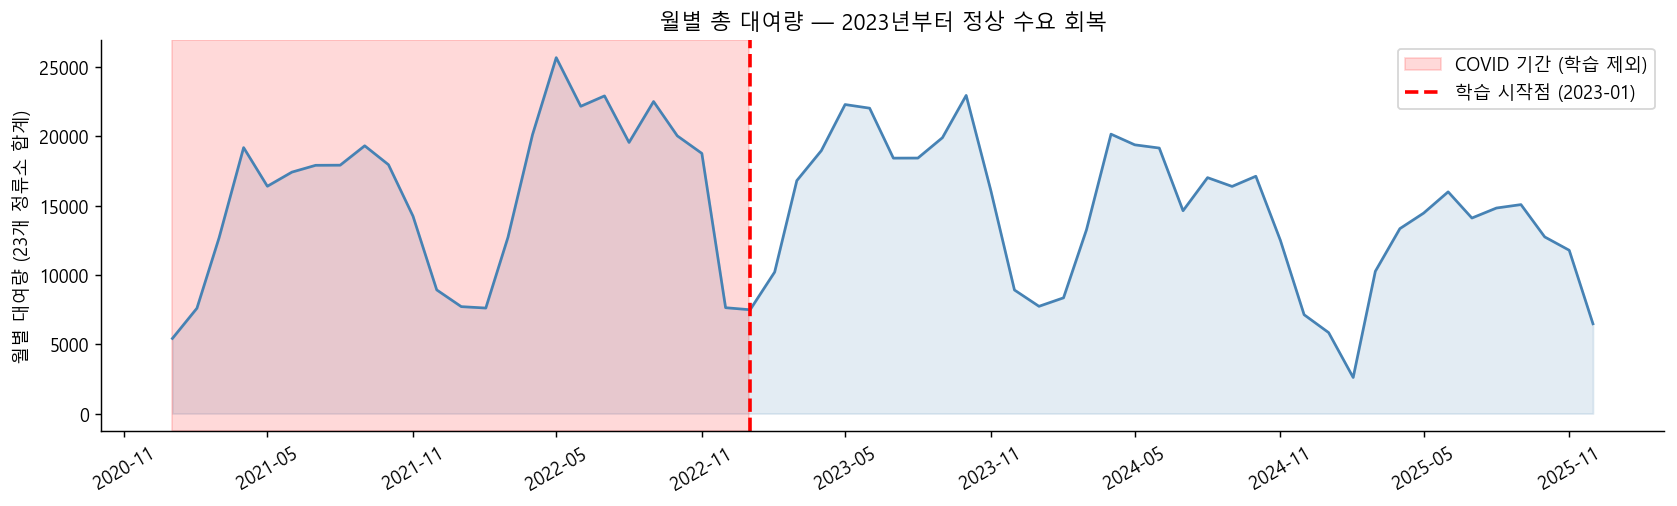

In [59]:

# ── 연도별 수요 추이 — 2023+ 선택 근거 ────────────────────────────
# [발표] "2021~2022는 COVID로 수요가 비정상적으로 낮음"
#        "2023년부터 정상 수요 회복 → 이 기간만 학습에 사용"

# 월(Period) 단위로 집계: 23개 정류소 합산
monthly = (
    df_raw
    .assign(ym=df_raw['datetime'].dt.to_period('M'))   # 'YYYYMM' Period 컬럼 생성
    .groupby('ym')['CNT'].sum()                         # 월별 대여량 합산
    .reset_index()
)
monthly['dt'] = monthly['ym'].dt.to_timestamp()        # 플롯용 datetime 변환

# ── 시각화 ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

# 월별 대여량 선 그래프 + 면적 채우기
ax.plot(monthly['dt'], monthly['CNT'], color='steelblue', linewidth=1.5)
ax.fill_between(monthly['dt'], monthly['CNT'], alpha=0.15, color='steelblue')

# COVID 기간 음영: 이 구간을 학습에서 제외하는 이유를 시각적으로 강조
ax.axvspan(pd.Timestamp('2021-01-01'), pd.Timestamp('2022-12-31'),
           alpha=0.15, color='red', label='COVID 기간 (학습 제외)')

# 학습 시작점 표시
ax.axvline(pd.Timestamp('2023-01-01'), color='red', linestyle='--',
           linewidth=2, label='학습 시작점 (2023-01)')

ax.set_title('월별 총 대여량 — 2023년부터 정상 수요 회복')
ax.set_ylabel('월별 대여량 (23개 정류소 합계)')

# x축: 6개월 간격으로 연-월 표시
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


---
## 3. EDA — 모델링 결정 근거
> **[발표]** 그래프 보여주면서 "이래서 S=24 고정", "이래서 평일/주말 분리" 순서로 설명

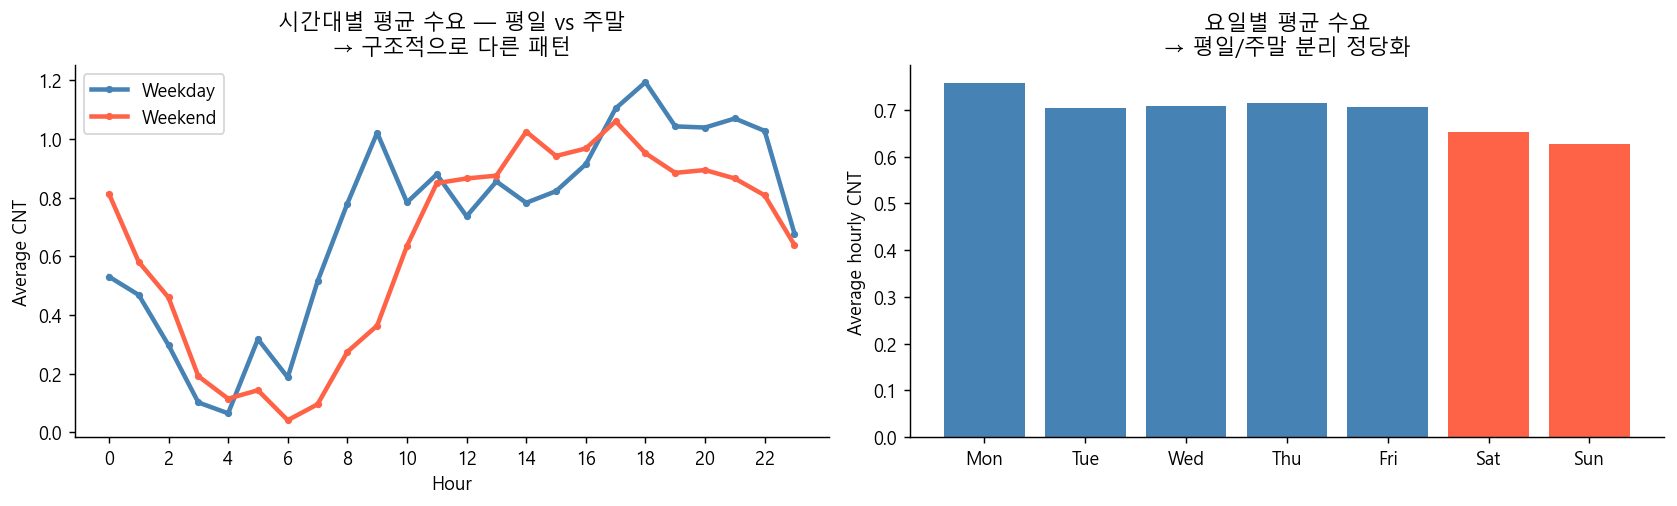

In [55]:

# ── 평일 vs 주말 시간대 패턴 — 평일/주말 분리 근거 ──────────────────
# [발표] "평일은 출퇴근 더블 피크(8시, 18시), 주말은 오후 단일 피크"
#        "하나의 모델로 두 패턴을 동시에 잡을 수 없어 분리 학습"

# 시간대·요일 분석용 피처 생성
df_pat = pd.DataFrame({'CNT': series})
df_pat['hour']       = df_pat.index.hour           # 시간대 (0~23)
df_pat['dayofweek']  = df_pat.index.dayofweek      # 요일 (0=월 ~ 6=일)
df_pat['is_weekend'] = df_pat.index.dayofweek >= 5 # True = 토·일

dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── 왼쪽: 시간대별 평균 수요 (평일 vs 주말) ──────────────────────
for is_wknd, label, color in [
    (False, 'Weekday', 'steelblue'),
    (True,  'Weekend', 'tomato'),
]:
    hourly = (df_pat[df_pat['is_weekend'] == is_wknd]
              .groupby('hour')['CNT'].mean())
    axes[0].plot(hourly.index, hourly.values,
                 label=label, color=color, linewidth=2.5,
                 marker='o', markersize=3)

axes[0].set_title('시간대별 평균 수요 — 평일 vs 주말\n→ 구조적으로 다른 패턴')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Average CNT')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()

# ── 오른쪽: 요일별 평균 수요 ─────────────────────────────────────
daily = df_pat.groupby('dayofweek')['CNT'].mean()

# 평일(월~금)은 파란색, 주말(토·일)은 빨간색으로 구분
bar_colors = ['steelblue'] * 5 + ['tomato'] * 2
axes[1].bar([dow_names[i] for i in daily.index], daily.values, color=bar_colors)
axes[1].set_title('요일별 평균 수요\n→ 평일/주말 분리 정당화')
axes[1].set_ylabel('Average hourly CNT')

plt.tight_layout()
plt.show()


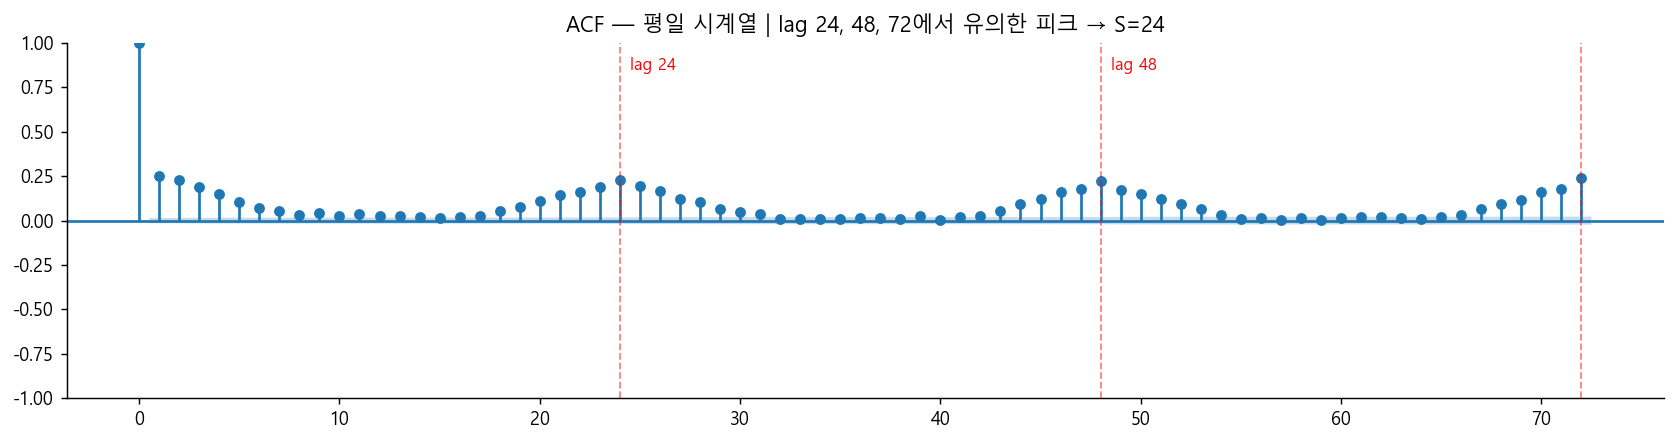

In [56]:

# ── ACF — S=24 계절 주기 정당화 ───────────────────────────────────
# [발표] "lag 24, 48, 72에서 반복 스파이크 → 정확히 24시간 주기 계절성"
#        "이것이 SARIMA seasonal period S=24로 고정하는 근거"

# 평일 시계열만 사용: 주말 패턴이 섞이면 ACF가 흐려짐
s_wd = series[series.index.dayofweek < 5]

fig, ax = plt.subplots(figsize=(13, 3.5))

# lag=72: 3일치(72시간)까지 보여줌으로써 24 주기가 반복됨을 확인
plot_acf(s_wd.dropna(), lags=72, ax=ax,
         title='ACF — 평일 시계열 | lag 24, 48, 72에서 유의한 피크 → S=24')

# 24 배수 위치에 수직선으로 스파이크 위치 강조
for lag in [24, 48, 72]:
    ax.axvline(lag, color='red', linestyle='--', alpha=0.5, linewidth=1)

ax.text(24.5, ax.get_ylim()[1] * 0.85, 'lag 24', color='red', fontsize=9)
ax.text(48.5, ax.get_ylim()[1] * 0.85, 'lag 48', color='red', fontsize=9)

plt.tight_layout()
plt.show()


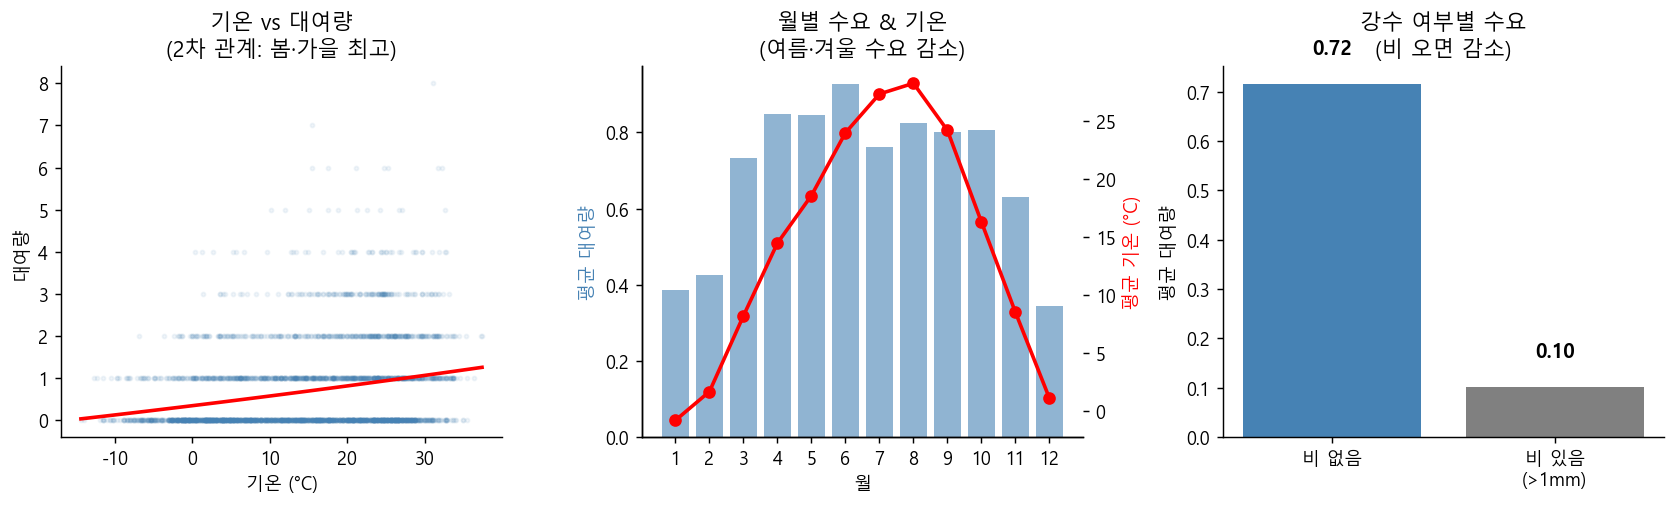

In [57]:

# ── 기상 외생변수 근거 ─────────────────────────────────────────────
# [발표] "기온-수요 2차 관계: 너무 추워도, 너무 더워도 대여 감소"
#        "비 오는 날은 수요 명확히 감소 → 외생변수 포함 정당화"

# 분석용 데이터프레임 구성
df_w = pd.DataFrame({'CNT': series})

# 기상 데이터를 시계열 인덱스에 맞춰 reindex 후 전방 채움(ffill)
df_w['temp'] = weather_df['temp'].reindex(df_w.index).ffill()

if HAS_RAIN:
    rain_col     = 'rainfall' if 'rainfall' in weather_df.columns else 'rain'
    df_w['rain'] = weather_df[rain_col].reindex(df_w.index).fillna(0)
    df_w['is_rain'] = df_w['rain'] > 1.0   # 1mm 이상을 '비 있음'으로 정의

df_w['month'] = df_w.index.month
df_w = df_w.dropna()   # 기상 데이터 누락 행 제거

ncols = 3 if HAS_RAIN else 2
fig, axes = plt.subplots(1, ncols, figsize=(13, 4))

# ── 왼쪽: 기온 vs 대여량 산점도 ──────────────────────────────────
# 3,000개 샘플링: 전체 플롯 시 렌더링 느림 방지
samp = df_w.sample(min(3000, len(df_w)), random_state=42)
axes[0].scatter(samp['temp'], samp['CNT'], alpha=0.08, s=5, color='steelblue')

# 2차 다항 추세선: 기온-수요의 비선형(역U자) 관계 표현
z      = np.polyfit(samp['temp'], samp['CNT'], 2)
tr     = np.linspace(samp['temp'].min(), samp['temp'].max(), 100)
axes[0].plot(tr, np.poly1d(z)(tr), color='red', linewidth=2)
axes[0].set_xlabel('기온 (°C)')
axes[0].set_ylabel('대여량')
axes[0].set_title('기온 vs 대여량\n(2차 관계: 봄·가을 최고)')

# ── 가운데: 월별 수요 & 기온 이중 축 ─────────────────────────────
m_avg = df_w.groupby('month')[['CNT', 'temp']].mean()
ax2b  = axes[1].twinx()   # 오른쪽 y축 (기온용)

axes[1].bar(m_avg.index, m_avg['CNT'], color='steelblue', alpha=0.6, label='수요')
ax2b.plot(m_avg.index, m_avg['temp'], color='red', marker='o',
          linewidth=2, label='기온')

axes[1].set_xticks(range(1, 13))
axes[1].set_xlabel('월')
axes[1].set_ylabel('평균 대여량', color='steelblue')
ax2b.set_ylabel('평균 기온 (°C)', color='red')
axes[1].set_title('월별 수요 & 기온\n(여름·겨울 수요 감소)')

# ── 오른쪽: 강수 여부별 수요 비교 (HAS_RAIN인 경우만) ─────────────
if HAS_RAIN:
    ra   = df_w.groupby('is_rain')['CNT'].mean()
    bars = axes[2].bar(['비 없음', '비 있음\n(>1mm)'],
                        ra.values, color=['steelblue', 'gray'])
    # 막대 위에 수치 표시
    for b, v in zip(bars, ra.values):
        axes[2].text(b.get_x() + b.get_width() / 2, v + 0.05,
                     f'{v:.2f}', ha='center', va='bottom',
                     fontsize=11, fontweight='bold')
    axes[2].set_ylabel('평균 대여량')
    axes[2].set_title('강수 여부별 수요\n(비 오면 감소)')

plt.tight_layout()
plt.show()


---
## 4. 모델링
> **[발표]** 각 모델을 한 슬라이드씩. 수식보다 직관적 설명 위주.  
> SARIMA → ARIMAX (외생변수 추가) → RF → XGBoost (비대칭 손실) 흐름으로

### 모델 구성

| 모델 | 특징 | 외생변수 |
|------|------|----------|
| **SARIMA** `(2,0,1)×(1,1,0,24)` | 통계 시계열, S=24 계절성 | ✗ |
| **ARIMAX** `(2,0,1)×(1,1,0,24)` | SARIMA + 기온·강수 | ✓ |
| **Random Forest** | 트리 앙상블, lag/시간 피처 | ✓ |
| **XGBoost** | Gradient Boosting | ✓ |
| **XGBoost (α=2)** | 비대칭 손실 — 과소예측 2× 패널티 | ✓ |

**ML 공통 피처**: `hour`, `dayofweek`, `month`, `lag_1`, `lag_24`, `lag_168`, `rolling_mean_24/168`, `temp`, `rain`

```python
# XGBoost 비대칭 손실 핵심 코드
def asymmetric_obj(y_pred, dtrain, alpha=2.0):
    errors = y_pred - dtrain.get_label()
    grad = np.where(errors < 0, alpha * 2 * errors, 2 * errors)  # 과소예측에 α배
    hess = np.where(errors < 0, alpha * 2, 2)
    return grad, hess
```

---
## 5. 결과 비교
> **[발표]** 표 먼저 보여주고 → 그래프로 시각화  
> "RMSE만 보면 ARIMAX/XGBoost가 좋지만, 과소예측률 보면 ARIMAX가 46%로 최악"  
> "Asym.RMSE + 과소예측률 동시에 낮은 게 XGBoost(α=2)"

=== Station 02128 평일 성능 비교 ===
                RMSE  Asym_RMSE  Under%
model                                  
SARIMA         0.640      0.750    26.2
ARIMAX         0.599      0.790    46.2
Random Forest  0.601      0.762    27.9
XGBoost        0.599      0.763    27.9
XGBoost (α=2)  0.650      0.761    26.4


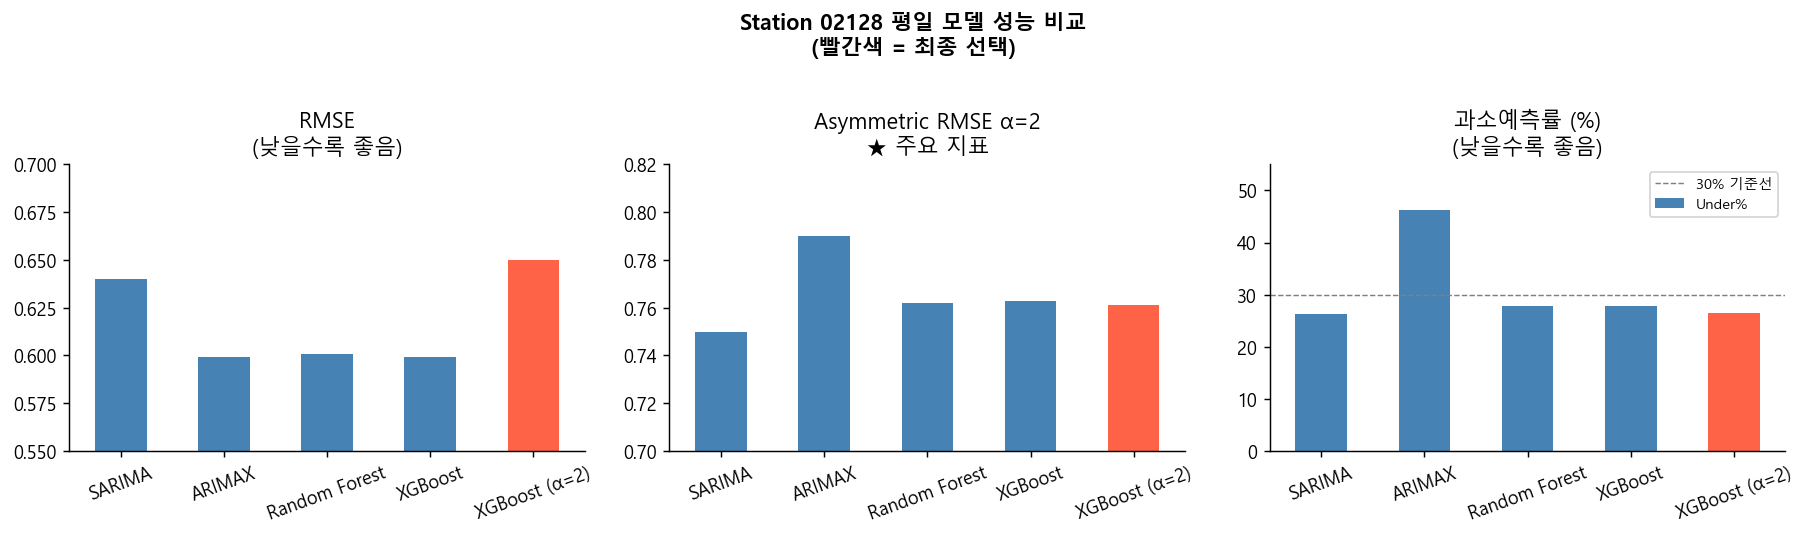

In [58]:

# ── 모델 성능 비교 (station 02128, 평일) ──────────────────────────
# [발표] "RMSE만 보면 ARIMAX·XGBoost가 좋아 보이지만"
#        "과소예측률 보면 ARIMAX가 46%로 최악 — 자전거 거의 항상 부족 예측"
#        "Asym.RMSE + 과소예측률 동시에 낮은 XGBoost(α=2)가 최선"

# 기존 실험 결과 수동 입력 (station 02128, 평일 기준)
results = pd.DataFrame([
    {'model': 'SARIMA',        'RMSE': 0.640, 'Asym_RMSE': 0.750, 'Under%': 26.2},
    {'model': 'ARIMAX',        'RMSE': 0.599, 'Asym_RMSE': 0.790, 'Under%': 46.2},
    {'model': 'Random Forest', 'RMSE': 0.601, 'Asym_RMSE': 0.762, 'Under%': 27.9},
    {'model': 'XGBoost',       'RMSE': 0.599, 'Asym_RMSE': 0.763, 'Under%': 27.9},
    {'model': 'XGBoost (α=2)', 'RMSE': 0.650, 'Asym_RMSE': 0.761, 'Under%': 26.4},
]).set_index('model')

print('=== Station 02128 평일 성능 비교 ===')
print(results.to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 최종 선택 모델(XGBoost α=2)을 빨간색으로 강조, 나머지는 파란색
colors = ['steelblue', 'steelblue', 'steelblue', 'steelblue', 'tomato']

# ── 왼쪽: RMSE ────────────────────────────────────────────────────
results['RMSE'].plot(kind='bar', ax=axes[0], color=colors, rot=20)
axes[0].set_title('RMSE\n(낮을수록 좋음)')
axes[0].set_ylim(0.55, 0.70)   # y축 범위 고정: 차이 부각

# ── 가운데: Asymmetric RMSE (주요 지표) ──────────────────────────
results['Asym_RMSE'].plot(kind='bar', ax=axes[1], color=colors, rot=20)
axes[1].set_title('Asymmetric RMSE α=2\n★ 주요 지표')
axes[1].set_ylim(0.70, 0.82)

# ── 오른쪽: 과소예측률 ───────────────────────────────────────────
results['Under%'].plot(kind='bar', ax=axes[2], color=colors, rot=20)
axes[2].set_title('과소예측률 (%)\n(낮을수록 좋음)')
axes[2].set_ylim(0, 55)
# 30% 기준선: 이 이상이면 자전거 부족이 너무 빈번함을 표시
axes[2].axhline(30, color='gray', linestyle='--', linewidth=0.8, label='30% 기준선')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel('')

plt.suptitle('Station 02128 평일 모델 성능 비교\n(빨간색 = 최종 선택)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 6. Limitation & 결론
> **[발표]** 한계점 솔직하게 인정하고, 향후 방향 제시로 마무리

### Limitation

1. **Demand Censoring**  
   자전거 재고가 없으면 관측 수요 < 실제 수요. 비대칭 손실로 부분 완화했으나 근본 해결 아님.

2. **공통 차수 적용**  
   auto_arima를 대표 정류소에서 찾아 23개에 동일 적용. 정류소별 최적 차수는 다를 수 있음.

3. **잔차 ACF 미해소**  
   lag 24, 48에 자기상관 잔존 — 주간 계절성(S=168)이 완전히 반영되지 않음.

---

### 결론

| | |
|--|--|
| **최선 모델** | XGBoost (비대칭 손실 α=2) |
| **이유** | Asym.RMSE 최저 + 과소예측률 균형 |
| **향후** | 23개 정류소 예측 → 재배치 권고 전략 수립 |